# Goal

Decomposite the orbital decay curve into trend and seasonal components usint Lomb-Scargle and STL.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from utils.data_loader import find_repo_root
from pathlib import Path
from statsmodels.tsa.seasonal import STL
from utils.data_loader import load_parquet
from utils.plot_loader import plot_lombscargle_periodogram

# Data

In [2]:
# Load only specific columns that you need for analysis
# This will significantly reduce memory usage
columns_needed = ['time', 'orbital_decay']

GFOC_data = load_parquet(columns=columns_needed)
print(GFOC_data.head())

✅ Successfully loaded data with shape: (3157920, 2)
                 time  orbital_decay
0 2023-01-01 00:00:00        16.6730
1 2023-01-01 00:00:20        16.6730
2 2023-01-01 00:00:40        16.6735
3 2023-01-01 00:01:00        16.6740
4 2023-01-01 00:01:20        16.6740


Lets have a look at the raw data:

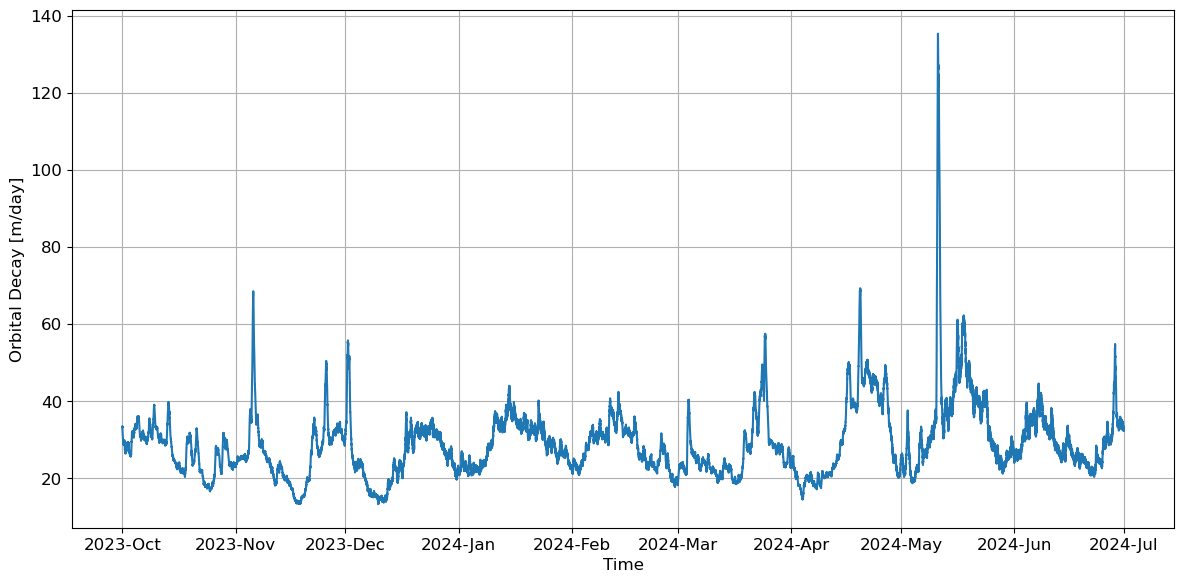

In [3]:
from utils.plot_loader import plot_orbital_decay

# =========================== Input ===================================
start_date = '2023-10-01 00:00:00'
end_date = '2024-07-01 00:00:00'
# start_date = pd.to_datetime(GFOC_data['time'].iloc[0])
# end_date = pd.to_datetime(GFOC_data['time'].iloc[-1]) #removed gap by ignoring the last 4321 values (for csv)

# Add an option for monthly, daily, or hourly ticks
tick_interval = 'monthly'  # Change to 'monthly', 'daily', or 'hourly'
tick_step = 1  # Step for the ticks (e.g., every month =1, every 2 months = 2, etc)

Flags = False

plot_orbital_decay(GFOC_data, None, start_date, end_date, tick_interval, tick_step, FLAGS=Flags)

# STL filter

In [4]:
def stl_decomposition(y, day):
    period = int(day * 24 * 60 * 3) # 1: 22.77 days, 2: 
    print(f"using a period of {period/(180*24)} days")
    seasonal = 100 * period + ((100*period % 2) == 0)  # Ensure odd
    low_pass_jump = seasonal_jump = int(0.15 * (period + 1))
    trend_jump = int(0.15 * 1.5 * (period + 1))


    mod = STL(
        y['orbital_decay'],
        period=period,
        seasonal=seasonal,
        seasonal_jump=seasonal_jump,
        trend_jump=trend_jump,
        low_pass_jump=low_pass_jump,
        seasonal_deg=0,
        robust=True
    )
    %timeit mod.fit()
    res = mod.fit()

    # plot
    plt.rc("figure", figsize=(12, 10))
    plt.rc("font", size=13)
    fig = res.plot()
    return res

## 1. Remove trend using STL decomposition

using a period of 24.1 days
1min 31s ± 3.29 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


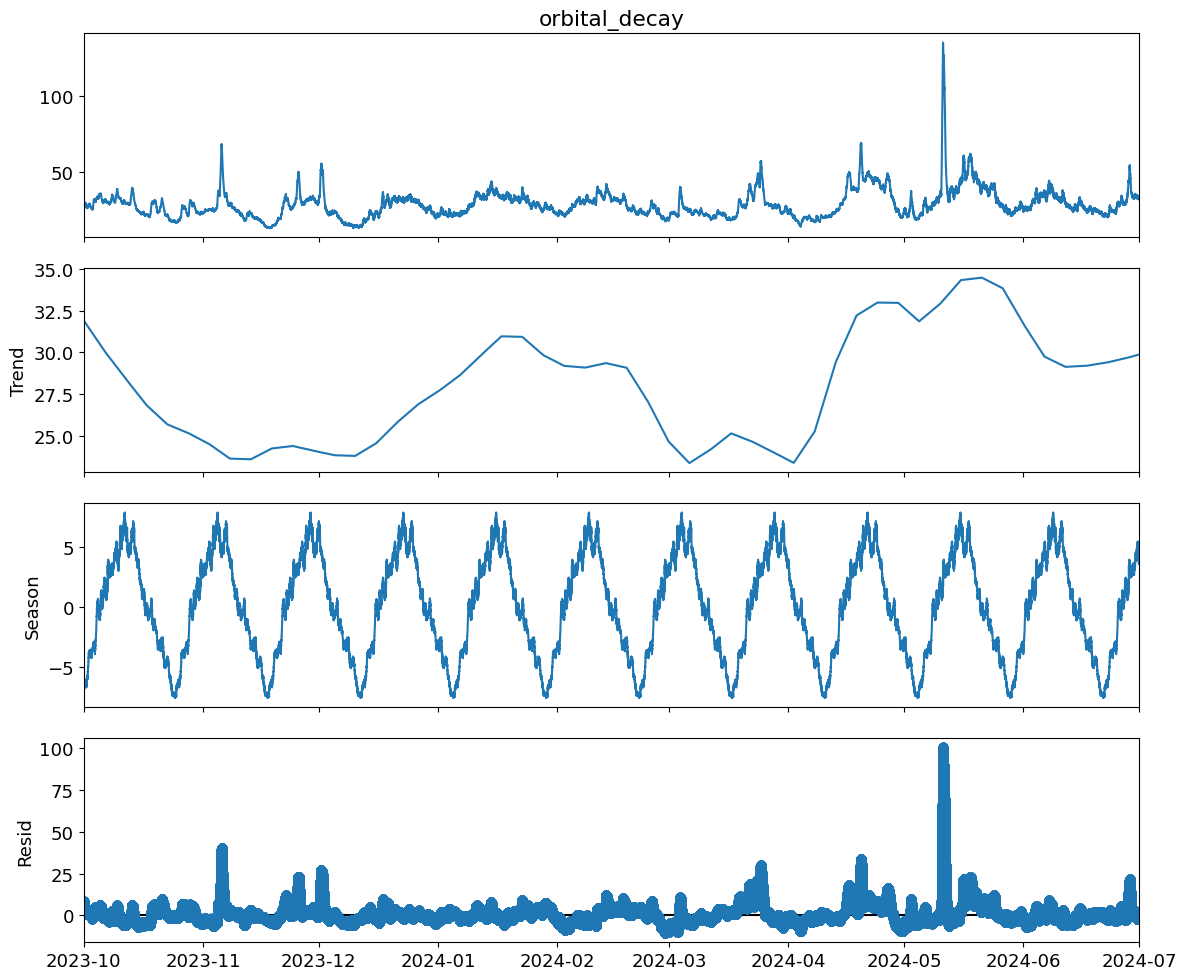

In [5]:
# Use time as index for y
GFOC_subset = GFOC_data[(GFOC_data['time'] >= start_date) & (GFOC_data['time'] <= end_date)].copy()
y = GFOC_subset[['time', 'orbital_decay']].copy()
y['time'] = pd.to_datetime(y['time'], format='%Y-%m-%d %H:%M:%S')
y.set_index('time', inplace=True)
# y.describe()

res_1 = stl_decomposition(y, 24.1)

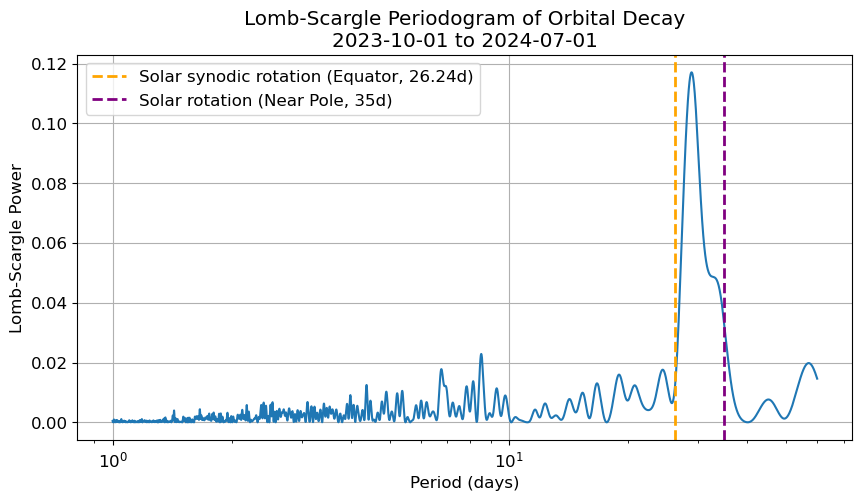

1. Period: 28.92 days (Power: 0.1171)
2. Period: 8.52 days (Power: 0.0229)
3. Period: 57.10 days (Power: 0.0198)
4. Period: 6.76 days (Power: 0.0178)
5. Period: 24.45 days (Power: 0.0176)
6. Period: 18.97 days (Power: 0.0160)
7. Period: 8.13 days (Power: 0.0137)
8. Period: 16.69 days (Power: 0.0130)
9. Period: 4.37 days (Power: 0.0125)
10. Period: 20.78 days (Power: 0.0124)


In [7]:
# GFOC_subset['trend_1'] = res_1.trend.values
GFOC_subset['seasonal_1'] = res_1.seasonal.values
GFOC_subset['residual'] = res_1.resid.values + res_1.trend.values

GFOC_subset['orbital_decay'] = GFOC_subset['residual']
# Lomb-Scargle analysis
plot_lombscargle_periodogram(GFOC_subset, start_date, end_date,
    min_period=1.0,   # days
    max_period=60,  # days
    show=False
)

## 2. Remove Periodic Signal and non-linear Trend

using a period of 28.919907407407408 days
1min 32s ± 1.6 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


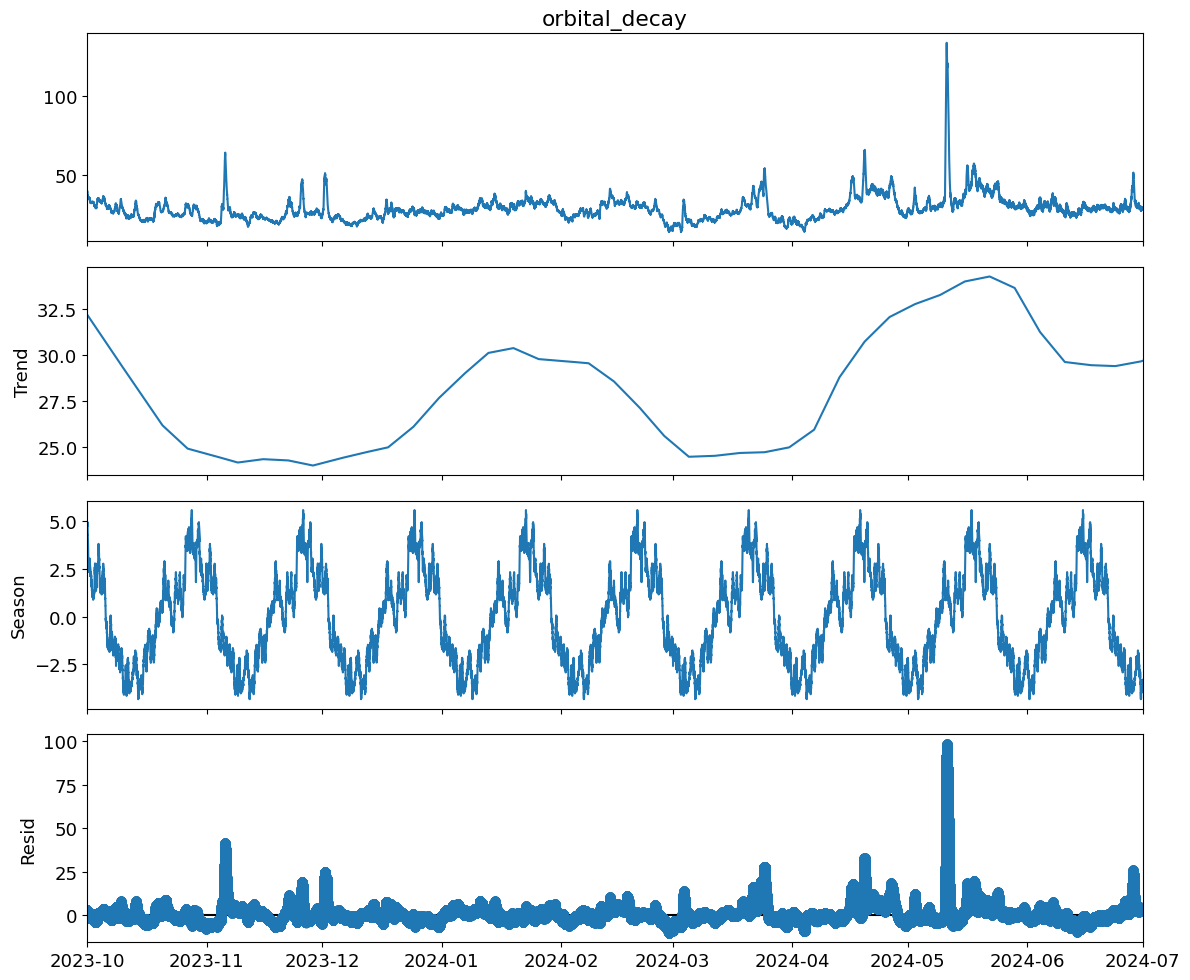

In [8]:
# Use time as index for y
y = GFOC_subset[['time', 'orbital_decay']].copy()
y['time'] = pd.to_datetime(y['time'], format='%Y-%m-%d %H:%M:%S')
y.set_index('time', inplace=True)
# y.describe()

res_2 = stl_decomposition(y, 28.92)

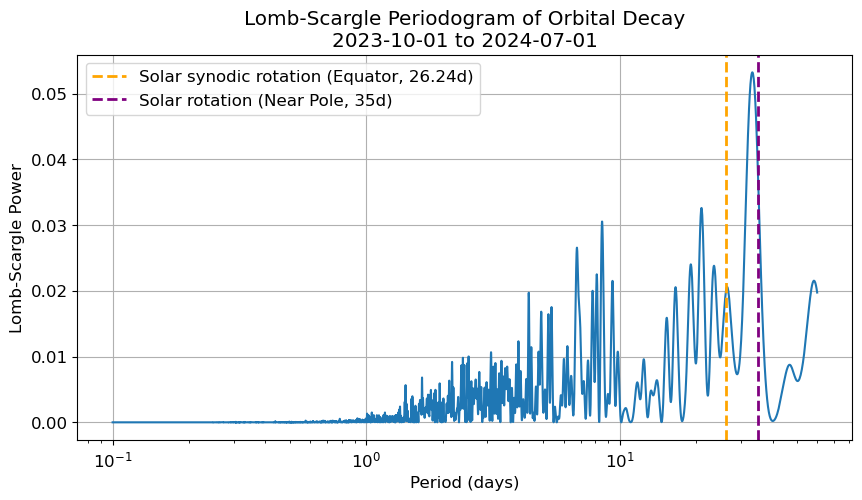

1. Period: 33.28 days (Power: 0.0533)
2. Period: 21.00 days (Power: 0.0326)
3. Period: 8.51 days (Power: 0.0306)
4. Period: 6.77 days (Power: 0.0266)
5. Period: 19.05 days (Power: 0.0240)
6. Period: 23.52 days (Power: 0.0238)
7. Period: 8.11 days (Power: 0.0225)
8. Period: 58.26 days (Power: 0.0216)
9. Period: 9.35 days (Power: 0.0215)
10. Period: 26.50 days (Power: 0.0206)


In [9]:
GFOC_subset['trend_1'] = res_2.trend.values
GFOC_subset['seasonal_2'] = res_2.seasonal.values
GFOC_subset['residual'] = res_2.resid.values

GFOC_subset['orbital_decay'] = GFOC_subset['residual']

# Lomb-Scargle analysis
plot_lombscargle_periodogram(GFOC_subset, start_date, end_date,
    min_period=0.1,   # days
    max_period=60,  # days
    show=False
)

## 3. Remove secondary seasonal components

using a period of 33.27986111111111 days
1min 33s ± 7.54 s per loop (mean ± std. dev. of 7 runs, 1 loop each)


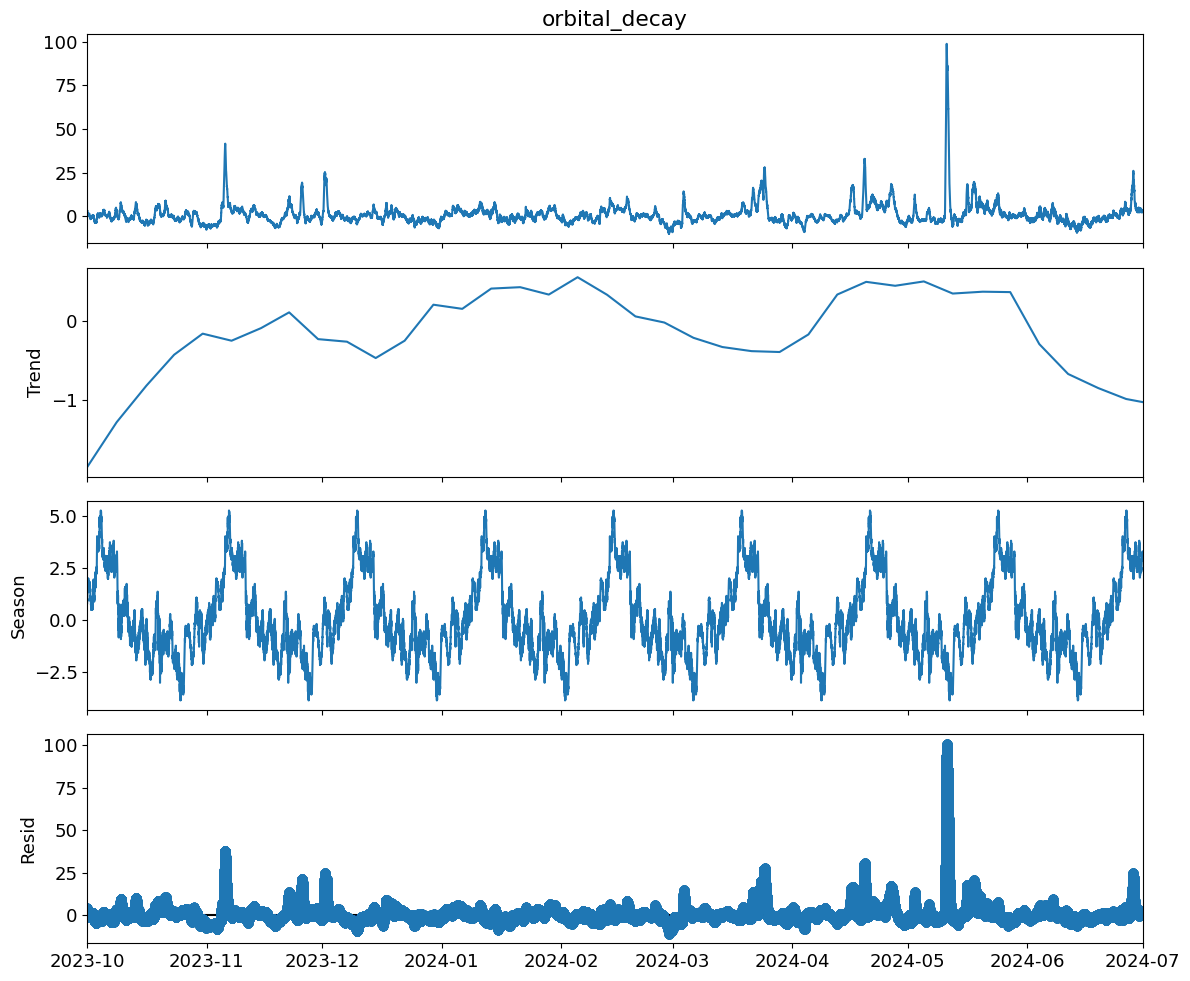

In [10]:
# Use time as index for y
y = GFOC_subset[['time', 'orbital_decay']].copy()
y['time'] = pd.to_datetime(y['time'], format='%Y-%m-%d %H:%M:%S')
y.set_index('time', inplace=True)
# y.describe()

res_3 = stl_decomposition(y, 33.28)

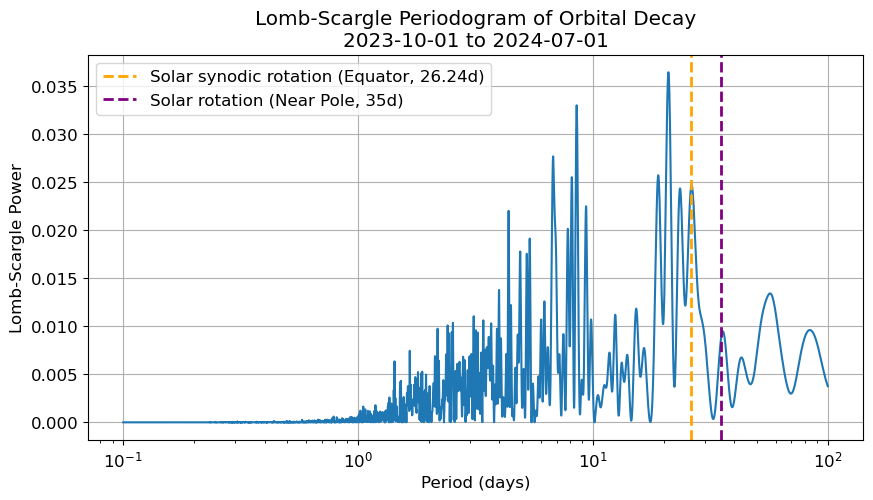

1. Period: 20.98 days (Power: 0.0364)
2. Period: 8.53 days (Power: 0.0330)
3. Period: 6.77 days (Power: 0.0277)
4. Period: 18.95 days (Power: 0.0257)
5. Period: 8.13 days (Power: 0.0255)
6. Period: 26.34 days (Power: 0.0247)
7. Period: 23.49 days (Power: 0.0243)
8. Period: 9.35 days (Power: 0.0225)
9. Period: 4.37 days (Power: 0.0220)
10. Period: 7.82 days (Power: 0.0201)


In [13]:
GFOC_subset['trend_2'] = res_3.trend.values
GFOC_subset['seasonal_3'] = res_3.seasonal.values
GFOC_subset['residual'] = res_3.resid.values

GFOC_subset['orbital_decay'] = GFOC_subset['residual']

# Lomb-Scargle analysis
plot_lombscargle_periodogram(GFOC_subset, start_date, end_date,
    min_period=0.1,   # days
    max_period=100,  # days
    show=False
)

# Plot Results

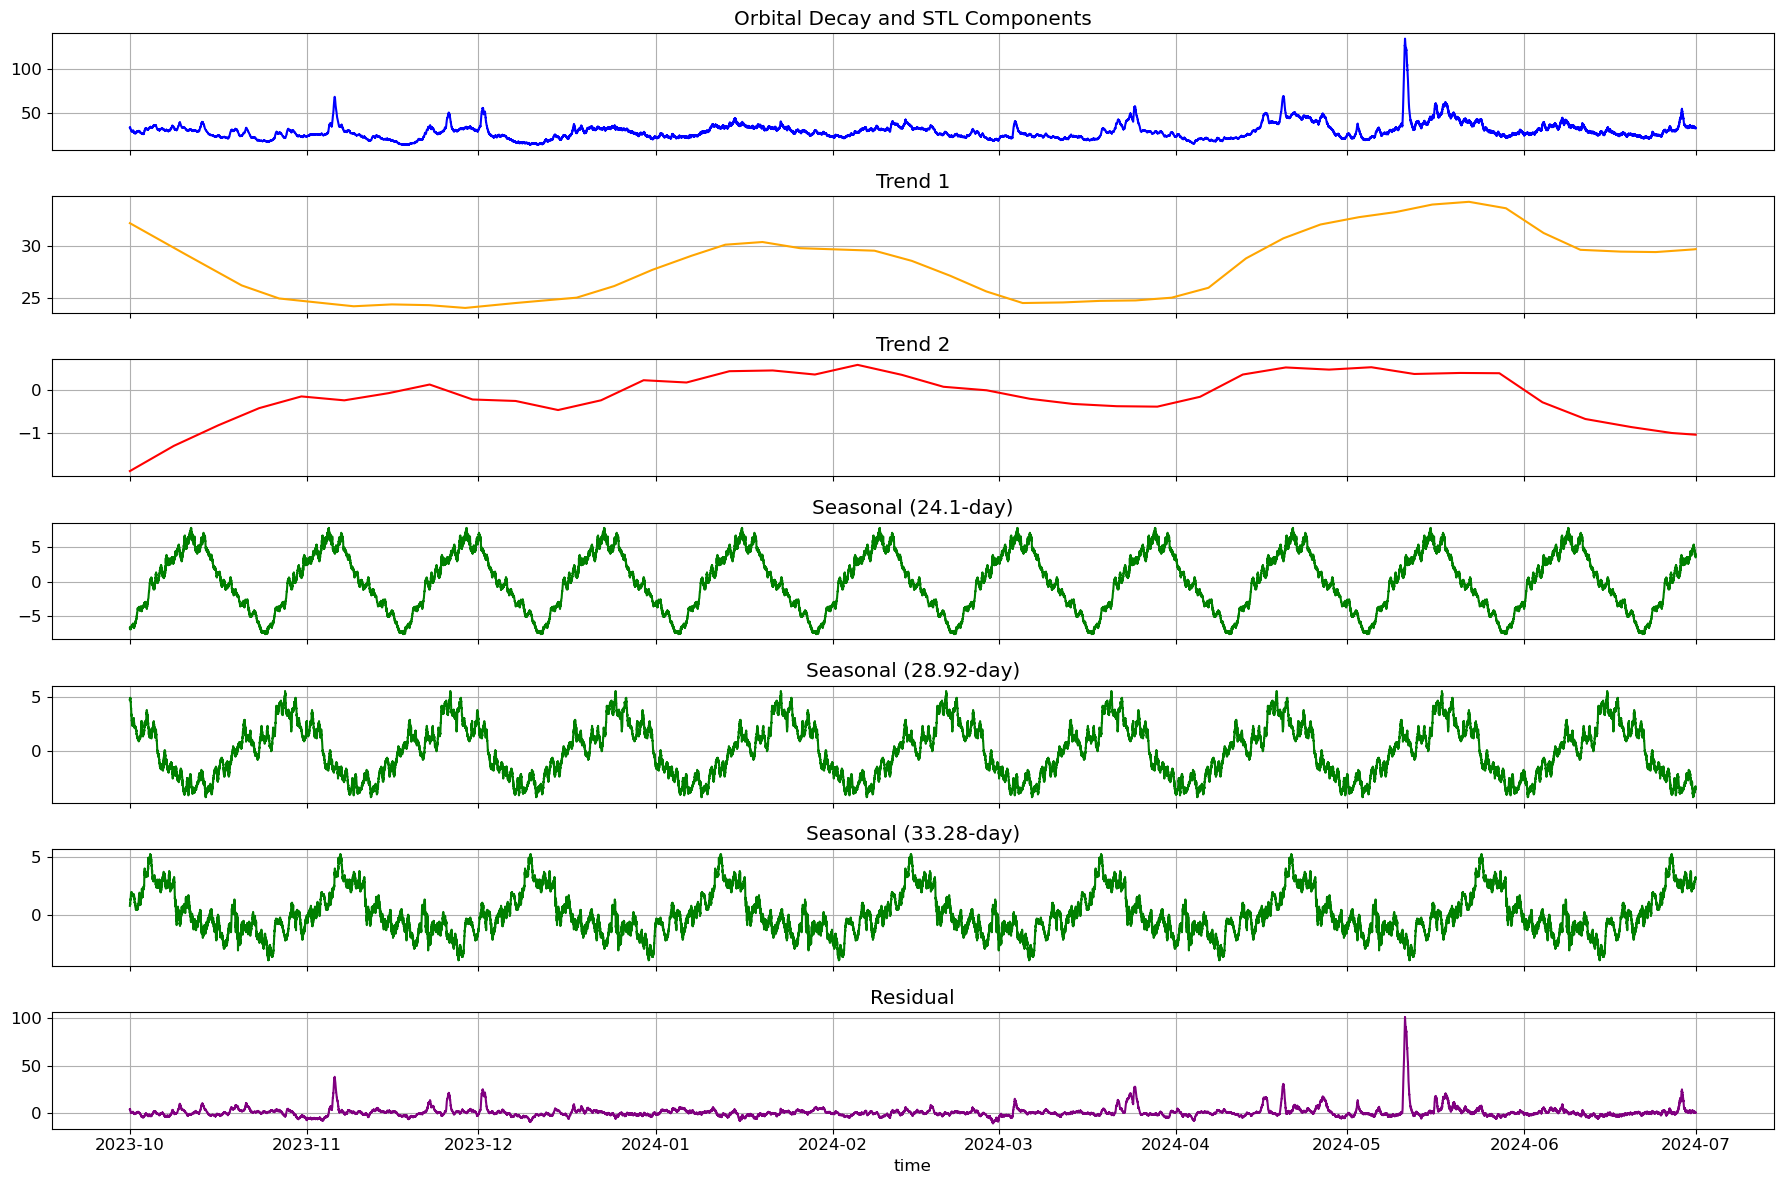

In [14]:
GFOC_subset['original_decay'] = GFOC_data['orbital_decay'].where(GFOC_data['time'].isin(GFOC_subset['time']))
# plot components
fig, axs = plt.subplots(7, 1, figsize=(18, 12), sharex=True)
axs[0].plot(GFOC_subset['time'], GFOC_subset['original_decay'], color='blue')
axs[0].set_title('Orbital Decay and STL Components')

axs[1].plot(GFOC_subset['time'], GFOC_subset['trend_1'], color='orange')
axs[1].set_title('Trend 1')

axs[2].plot(GFOC_subset['time'], GFOC_subset['trend_2'], color='red')
axs[2].set_title('Trend 2')

axs[3].plot(GFOC_subset['time'], GFOC_subset['seasonal_1'], color='green')
axs[3].set_title('Seasonal (24.1-day)')

axs[4].plot(GFOC_subset['time'], GFOC_subset['seasonal_2'], color='green')
axs[4].set_title('Seasonal (28.92-day)')

axs[5].plot(GFOC_subset['time'], GFOC_subset['seasonal_3'], color='green')
axs[5].set_title('Seasonal (33.28-day)')

axs[6].plot(GFOC_subset['time'], GFOC_subset['residual'], color='purple')
axs[6].set_title('Residual')

for ax in axs:
    # ax.legend()
    ax.grid()
plt.xlabel('time')
plt.tight_layout()
plt.show()